In [1]:
import ptime

import showdata
import numpy as np
start = "/bigdata/hplsim/production/marqua27/"
end = "/simOutput/openPMD/simData_%T.bp"
filename = start+"vacuum_propagation/flfoc_no_PIC_big"+end

iteration: 2000
absolute maximum: 305771500000.0


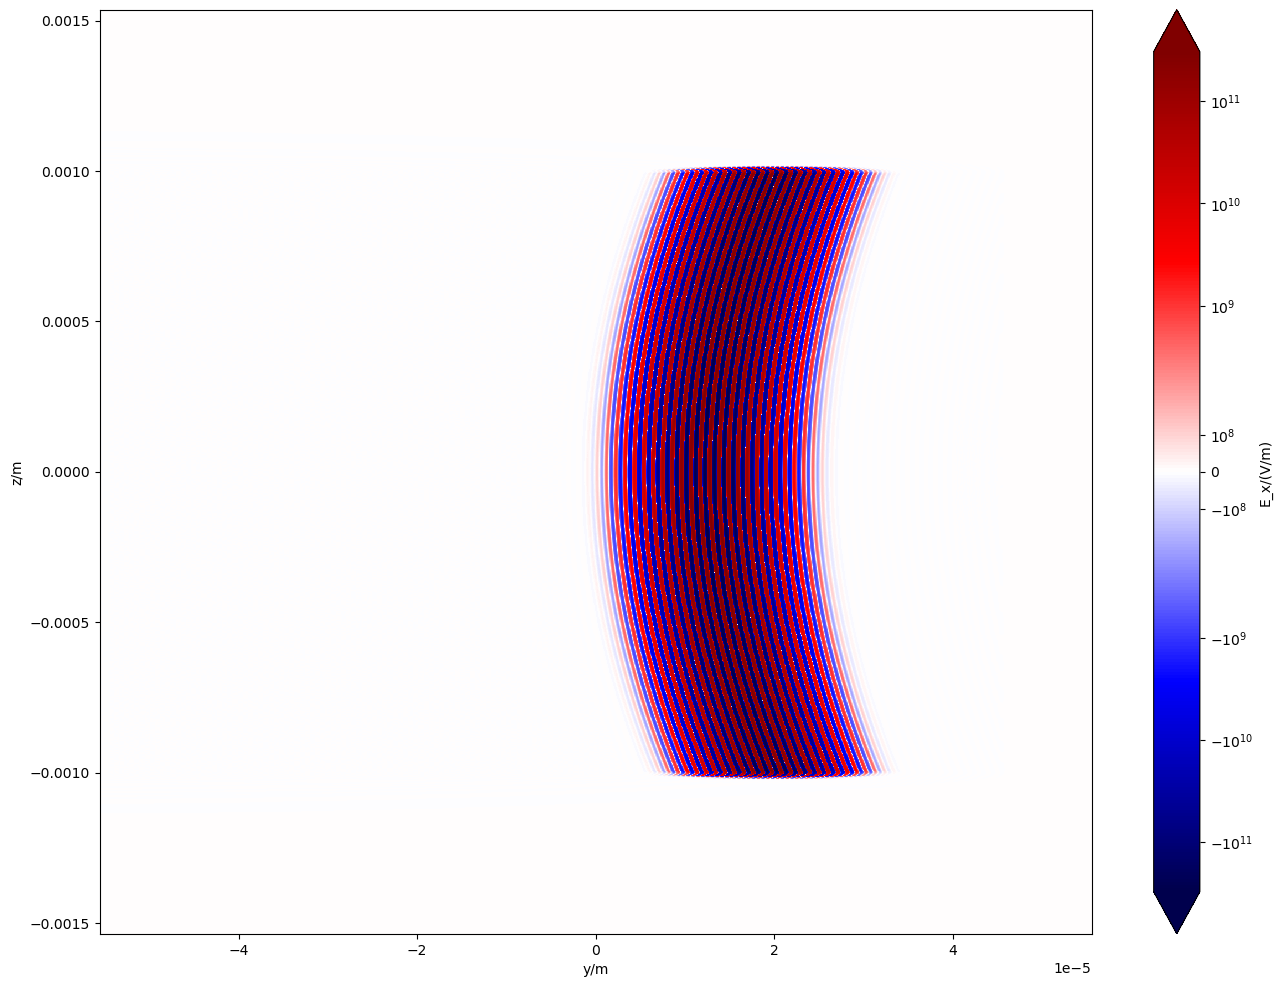

time showing file: 4 s 280 ms
runtime: 5 s 464 ms


In [2]:
showdata.show_file(filename, itstep=1, forward="y", show_time=True, linthresh_frac=0.001)
ptime.ptime()

In [3]:
from scipy.constants import c
import axiparabola_theory as axi
from lasy.optical_elements import Axiparabola
delta = 2e-3
f0 = 7e-2
w = 1e-3
R = 1.*w

calculating w


  0%|          | 00:00<? [?it/s]

maxtime reached
plotting w


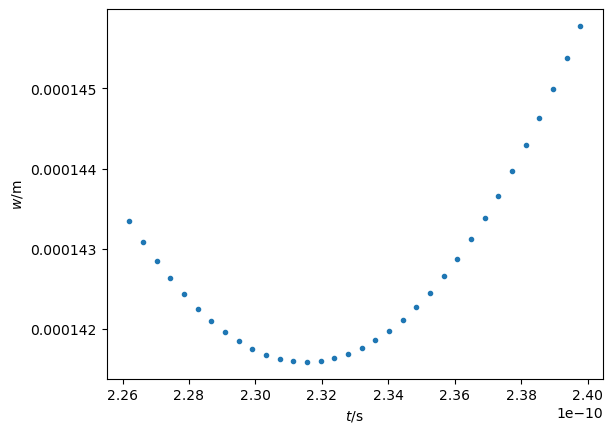

runtime: 36 min 44.381 s


In [4]:
# showdata.show_metadata(filename, iteration=6000)

def shouldbe(t):
    """theoretical w"""
    l_w = 10.54e-7
    return axi.wtf(t, Axiparabola(f0, delta, R), l_w)
showdata.plot_w(filename=filename, forward="y", startit=1137453, comp_func=shouldbe, maxtime=axi.tfz((f0+delta) * (1-1e-7), Axiparabola(f0, delta, R)))
ptime.ptime()

calculating lpeak


  0%|          | 00:00<? [?it/s]

maxtime reached
plotting lpeak


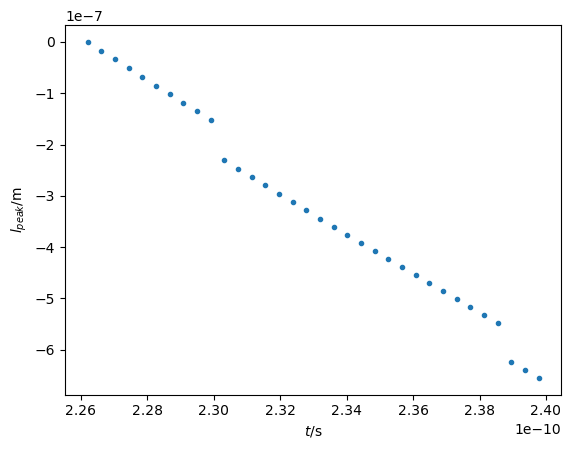

runtime: 1 h 12 min 7.2895 s


In [5]:

def shouldbe2(t):
    """theoretical value"""
    l_w = 10.54e-7
    tau = 1.5e-14
    return axi.ztf(t, Axiparabola(f0, delta, R))-c*t
showdata.plot_lpeak(filename=filename, forward="y", startit=1137453, 
                    comp_func=shouldbe2, maxtime=axi.tfz((f0+delta) * (1-2e-7), Axiparabola(f0, delta, R)),
                   apply_maxtime_to_measurement=True)
ptime.ptime()